1. divide my data to 5 year non-overlapping window in age (people 20-24, 25-29, 30-34 etc.)

2. Per ROI, and per age window, I want to find the slope of birth year (b1)
the regression model is:

for age_window:

GMV_ROI_1 ~ b1*birth_year

3. after calculating all b1 for all age windows, I want to present them in a plot (y axis is GMV, x axisis birth year).

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from tqdm import tqdm
import re
import nibabel as nib
from nilearn.image import new_img_like
from nilearn import plotting
from nilearn.datasets import load_mni152_template
import yabplot as yp

In [2]:
atlas_csv = pd.read_csv("/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv")
# print(f"networks: {atlas_csv['network'].unique()}")
# print(f"compoments: {atlas_csv['component'].unique()}")

In [3]:
coef_df = pd.read_csv('/home/gaia/Projects/legacy_data/legacy_pipe/data/interim/coef_df_manual_bins_wuniform.csv')

# take only interesting bins: (20, 25], (25, 30], (30, 35]
coef_df = coef_df[coef_df['age_bin'].isin(['(20, 25]', '(25, 30]', '(30, 35]'])]

unweighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'unweighted')
]
weighted_birth_year_coef_df = coef_df[
    (coef_df['variable'] == 'birth_year') & (coef_df['weighting'] == 'weighted')
]
# rename the column 'index' to 'region_label'
atlas_csv = atlas_csv.rename(columns={'index': 'region_label'})

# add the network and component information to the birth_year_coef_df
unweighted_birth_year_coef_df = unweighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')
weighted_birth_year_coef_df = weighted_birth_year_coef_df.merge(atlas_csv[['region_label', 'network', 'component', 'hemisphere']], on='region_label', how='left')

# Weighted vs. Unweighted 

# Weighted Analysis

In [4]:
birth_year_coef_df = weighted_birth_year_coef_df

stats_list = []
unique_bins = sorted(birth_year_coef_df['age_bin'].unique())

for bin_label in unique_bins:
    # Filter for this bin
    bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == bin_label]
    total_rois = bin_data['region_label'].nunique()
    
    # Filter for significant ROIs only
    sig_data = bin_data[bin_data['fdr_p'] < 0.05].copy() # Use .copy() to avoid SettingWithCopyWarning
    num_significant = sig_data.shape[0]
    
    # Calculate percentage
    percentage = (num_significant / total_rois * 100) if total_rois > 0 else 0
    
    # --- Create the combined network+component identifier ---
    # We join them with an underscore for easy reading
    if not sig_data.empty:
        sig_data['net_comp'] = sig_data['network'].astype(str) + "_" + sig_data['component'].astype(str)
        sig_net_comp_list = sig_data['net_comp'].unique().tolist()
        sig_roi_names = sig_data['region_name'].tolist()
        sig_roi_label = sig_data['region_label'].tolist()
    else:
        sig_net_comp_list = []
        sig_roi_names = []
        sig_roi_label = []

    print(f"Age Bin: {bin_label}")
    print(f"  Significant: {num_significant}/{total_rois} ({percentage:.2f}%)")

    # Add results to our list
    stats_list.append({
        'age_bin': bin_label,
        'num_significant': num_significant,
        'total_rois': total_rois,
        'percentage': percentage,
        'list_sig_net_comp': sig_net_comp_list, # The new combined column
        'list_sig_rois': sig_roi_names,
        'list_sig_roi_labels': sig_roi_label
    })

# Create the detailed DataFrame
bin_stats_detailed = pd.DataFrame(stats_list)

Age Bin: (20, 25]
  Significant: 270/454 (59.47%)
Age Bin: (25, 30]
  Significant: 242/454 (53.30%)
Age Bin: (30, 35]
  Significant: 215/454 (47.36%)


In [5]:
# --- Find repeating Network+Component combinations ---
# explode() expands the lists into individual rows
all_sig_net_comp = bin_stats_detailed['list_sig_net_comp'].explode()
net_comp_counts = all_sig_net_comp.value_counts()


print("\nNetwork + Component combinations that appear in multiple age bins:")
for combo, count in net_comp_counts.items():
    if count > 1:
        print(f"  {combo}: appears in {count} age bins")

# find the rois that appear in multiple age bins
all_sig_rois = bin_stats_detailed['list_sig_rois'].explode()
roi_counts = all_sig_rois.value_counts()

print("\nROIs that appear in multiple age bins:")
for roi, count in roi_counts.items():
    if count > 1:
        print(f"  {roi}: appears in {count} age bins")

# add the roi count to birth_year_coef_fd
birth_year_coef_df['roi_count'] = birth_year_coef_df['region_name'].map(roi_counts)


Network + Component combinations that appear in multiple age bins:
  visual_visual: appears in 3 age bins
  somatomotor_somatomotor: appears in 3 age bins
  dorsal attention_posterior: appears in 3 age bins
  dorsal attention_frontal eye fields: appears in 3 age bins
  dorsal attention_precentral ventral: appears in 3 age bins
  salience / ventral attention_parietal operculum: appears in 3 age bins
  salience / ventral attention_frontal operculum insula: appears in 3 age bins
  salience / ventral attention_medial: appears in 3 age bins
  limbic_orbital frontal cortex: appears in 3 age bins
  limbic_temporal pole: appears in 3 age bins
  control_lateral prefrontal cortex: appears in 3 age bins
  control_ventral prefrontal cortex: appears in 3 age bins
  control_cingulate: appears in 3 age bins
  default_temporal: appears in 3 age bins
  default_parietal: appears in 3 age bins
  default_prefrontal cortex: appears in 3 age bins
  default_precuneus posterior cingulate cortex: appears in 3

In [6]:
def string_to_interval(interval_str):
    if pd.isna(interval_str) or not isinstance(interval_str, str):
        return None
    # Remove brackets/parentheses and split by the dash
    # Note: This assumes your ages are always positive!
    clean_str = interval_str.strip("()[] ")
    # split by - or , 
    if "-" in clean_str:
        left, right = clean_str.split("-", 1)
    else:
        left, right = clean_str.split(",", 1)
    return pd.Interval(float(left), float(right), closed='right')

# 1. Convert strings to Interval objects
birth_year_coef_df['age_bin_interval'] = birth_year_coef_df['age_bin'].apply(string_to_interval)

birth_year_coef_df['mid_age_bin'] = birth_year_coef_df['age_bin_interval'].apply(lambda x: x.mid)

In [7]:
significant_birth_year_coef_df = birth_year_coef_df[birth_year_coef_df['fdr_p'] < 0.05]


# Visualization

# Visualizations on the brain

Linear regression and on to the brain 
The slope of birth year in each age window 
the effect of birth year in each age window

per bin

In [8]:
atlas_file_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_img = nib.load(atlas_file_path)
atlas_labels = atlas_img.get_fdata()

Found 54 subcortical regions to build meshes for.
filtered down to 54 subcortical regions to extract.
extracting: HIP-head-m1-rh (id 401)...
extracting: HIP-head-m2-rh (id 402)...
extracting: THA-VAip-rh (id 403)...
extracting: THA-VAia-rh (id 404)...
extracting: HIP-head-l-rh (id 405)...
extracting: HIP-body-rh (id 406)...
extracting: HIP-tail-rh (id 407)...
extracting: THA-VPm-rh (id 408)...
extracting: THA-VPl-rh (id 409)...
extracting: THA-VAs-rh (id 410)...
extracting: THA-DAm-rh (id 411)...
extracting: THA-DAl-rh (id 412)...
extracting: PUT-VA-rh (id 413)...
extracting: PUT-DA-rh (id 414)...
extracting: PUT-VP-rh (id 415)...
extracting: PUT-DP-rh (id 416)...
extracting: CAU-VA-rh (id 417)...
extracting: CAU-DA-rh (id 418)...
extracting: CAU-body-rh (id 419)...
extracting: CAU-tail-rh (id 420)...
extracting: lAMY-rh (id 421)...
extracting: mAMY-rh (id 422)...
extracting: THA-DP-rh (id 423)...
extracting: NAc-shell-rh (id 424)...
extracting: NAc-core-rh (id 425)...
extracting: pGP-

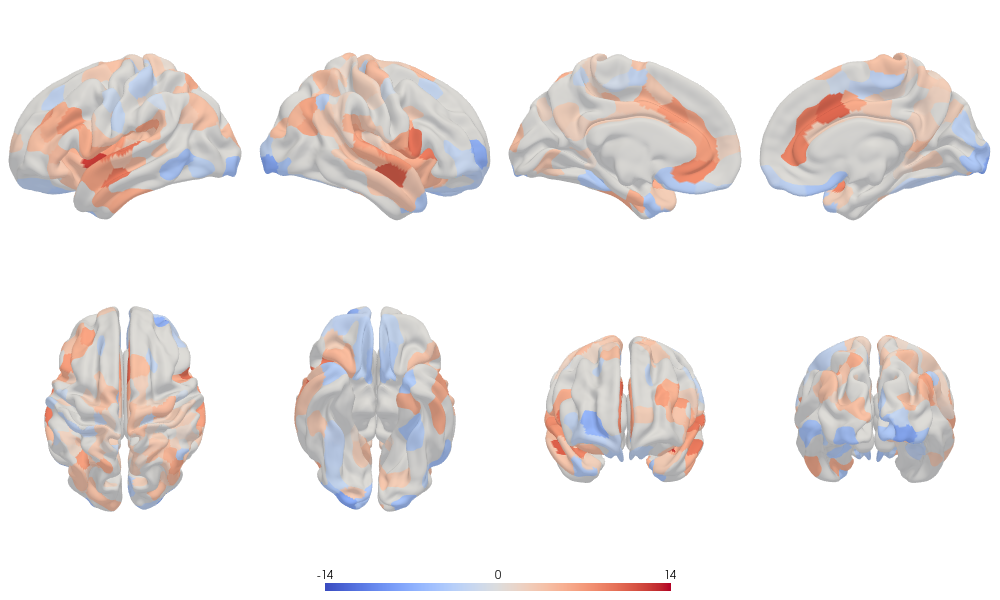

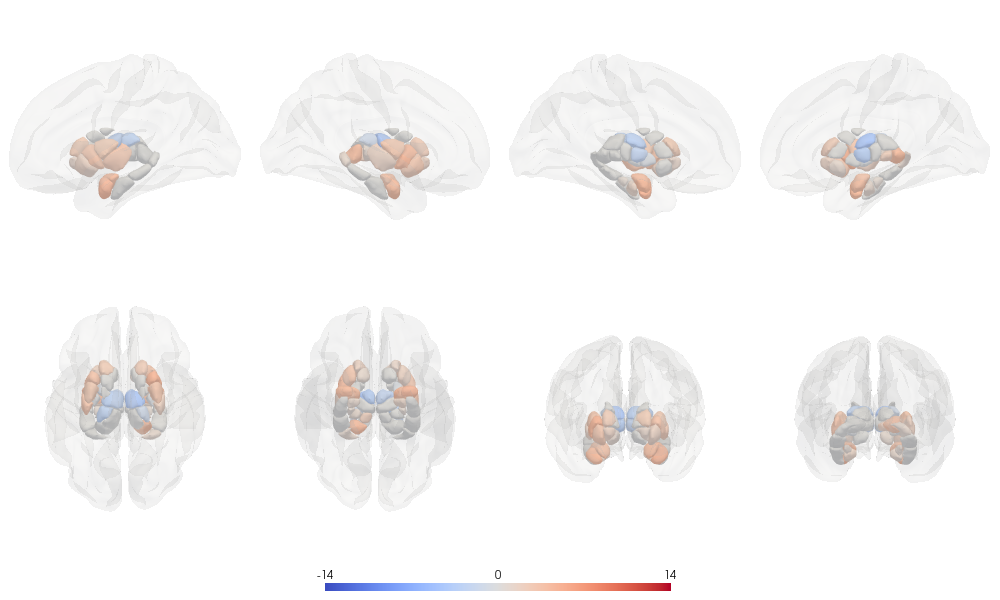

Processing age bin: (25, 30]


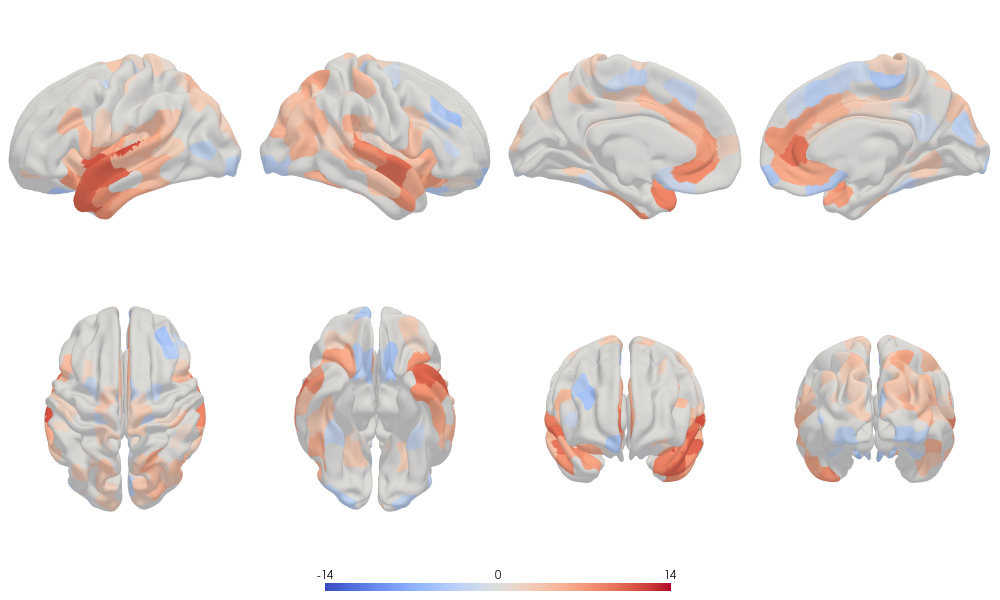

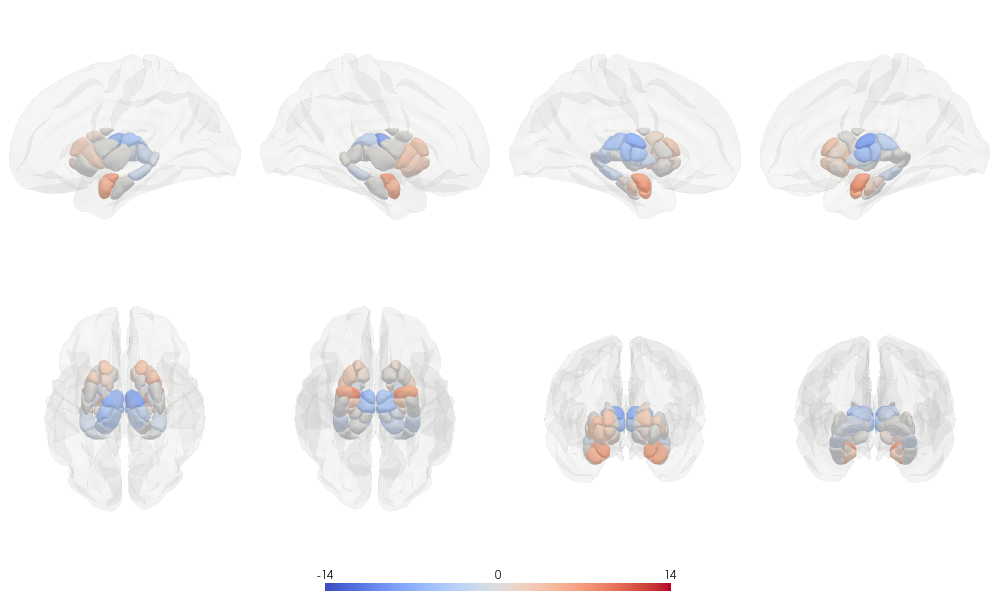

Processing age bin: (30, 35]


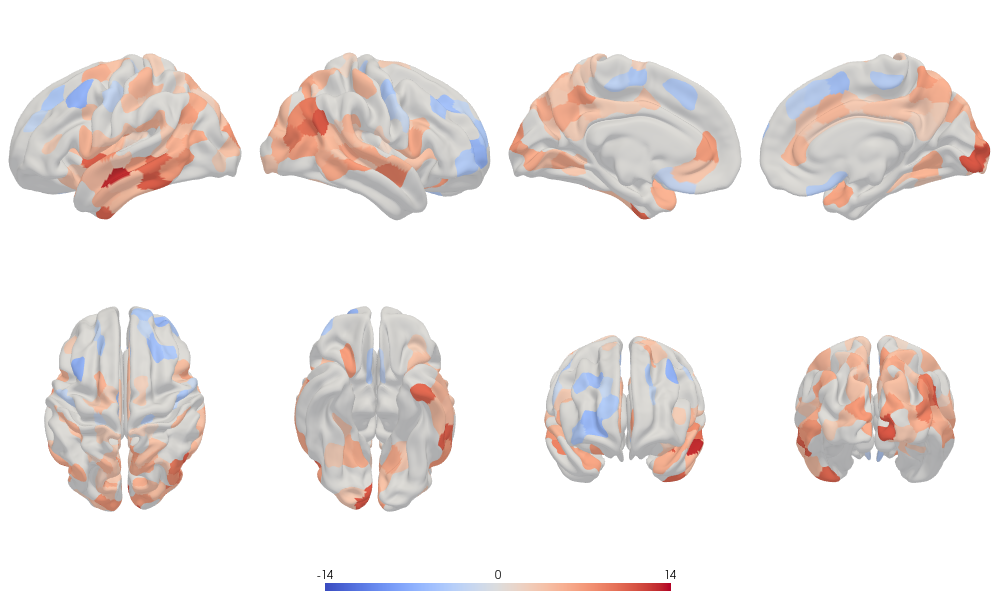

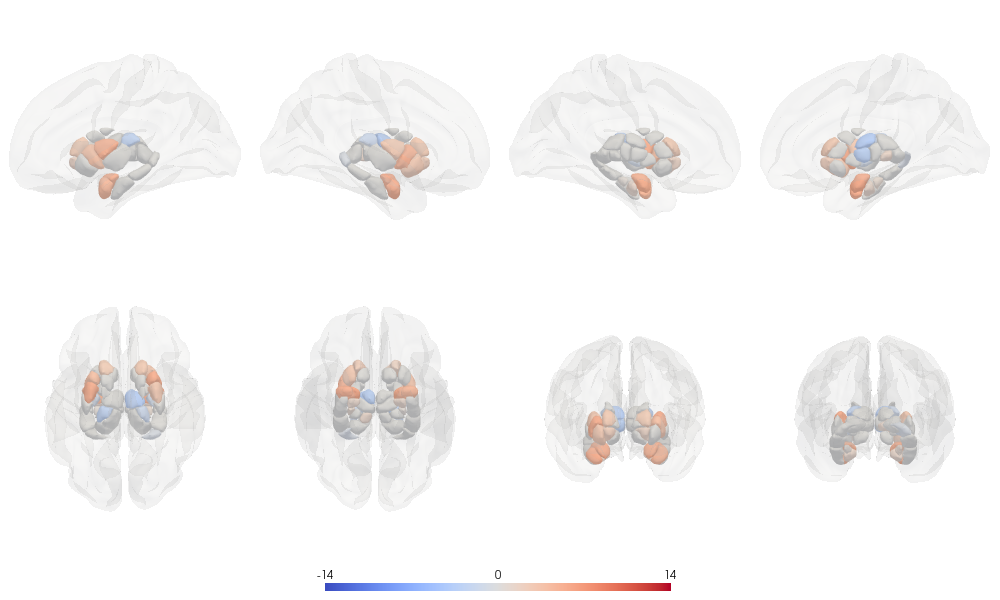

In [15]:
import os
import numpy as np
import pandas as pd
import yabplot as yab

# ── Atlas paths ───────────────────────────────────────────────────────────────
atlas_nii_path = '/media/storage/MATLAB_atlases-20250612T134418Z-1-001/MATLAB_atlases/schaefer2018tian2020_400_7.nii'
atlas_csv_path = '/home/gaia/Projects/legacy_data/my_master/space-MNI152_atlas-schaefer2018tian2020_res-1mm_den-400_div-7networks_dseg.csv'

# Output directory where yabplot will save the subcortical .vtk meshes
dir_custom_subcortical = 'my_custom_atlases/subcortical/tian2020_s7'

# ── Step 1: Parse atlas CSV into the {int_id: name} dict yabplot expects ──────
atlas_csv = pd.read_csv(atlas_csv_path)
atlas_labels = dict(zip(atlas_csv['index'], atlas_csv['name']))

# Subcortical only: indices 401-454 (no 7Networks_ prefix)
subcortical_labels = {
    idx: name for idx, name in atlas_labels.items()
    if not name.startswith('7Networks_')
}

print(f"Found {len(subcortical_labels)} subcortical regions to build meshes for.")

# ── Step 2: Build the subcortical mesh atlas (run ONCE, then reuse) ───────────
# This runs marching cubes + Laplacian smoothing and saves .vtk files to disk.
# Comment this block out after the first successful run.
if not os.path.exists(dir_custom_subcortical):
    yab.build_subcortical_atlas(
        nii_path=atlas_nii_path,
        labels_dict=subcortical_labels,
        out_dir=dir_custom_subcortical,
        smooth_i=20,   # smoothing iterations (same as tutorial default)
        smooth_f=0.5,  # smoothing factor
    )

# Optional: QC report to verify all 54 meshes built cleanly
# from yabplot.atlas_builder import qc_custom_subcortical_atlas
# qc_custom_subcortical_atlas(atlas_dir=dir_custom_subcortical)

# ── Step 3: Plot per age bin ───────────────────────────────────────────────────
for age_bin in birth_year_coef_df['age_bin'].unique():
    print(f'Processing age bin: {age_bin}')
    age_bin_data = birth_year_coef_df[birth_year_coef_df['age_bin'] == age_bin]

    # All regions default to NaN; overwrite significant ones with coef
    all_regions = age_bin_data['region_name'].unique()
    coef_dict = {region: np.nan for region in all_regions}
    for _, row in age_bin_data[age_bin_data['fdr_p'] < 0.05].iterrows():
        coef_dict[row['region_name']] = row['coef']

    # Split by naming convention
    cortical_data    = {k: v for k, v in coef_dict.items() if k.startswith('7Networks_')}
    subcortical_data = {k: v for k, v in coef_dict.items() if not k.startswith('7Networks_')}

    # ── Cortical: use built-in schaefer400 (no change needed) ─────────────────
    yp.plot_cortical(
        data=cortical_data,
        atlas='schaefer400',
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),
        display_type='static',
    )

    # ── Subcortical: use custom-built Tian2020 mesh atlas ─────────────────────
    yp.plot_subcortical(
        data=subcortical_data,
        custom_atlas_path=dir_custom_subcortical,  # folder of .vtk files
        vminmax=[-14, 14],
        nan_color=(0.85, 0.85, 0.85),
        display_type='static',
    )

# show ROIs to focus on the brain

Trends per ROI 
for all ROIs, no significance filter
Including the significance of the linear model

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# # Your specific ROIs
# roi_list = [421, 422, 448, 449]

# list rois that the roi_count == 3
roi_list = birth_year_coef_df[birth_year_coef_df['roi_count'] == 3]['region_label'].unique().tolist()


for region_of_interest in roi_list:
    # Filter data for the specific ROI
    region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest].copy()
    
    if region_data.shape[0] < 2:
        print(f"Not enough data points for region {region_of_interest} to plot.")
        continue

    # 1. Add significance flag for coloring
    region_data['is_significant'] = region_data['fdr_p'] < 0.05
    
    # 2. Fit Linear Regression
    model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
    # 3. Plotting
    plt.figure(figsize=(7, 4))
    
    # Draw the gray connecting line first
    sns.lineplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        color='lightgray',
        zorder=1,
        legend=False
    )
    
    # Draw colored markers on top
    # Significant = Teal/Blue, Non-significant = Gray
    sns.scatterplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        hue='is_significant',
        palette={True: 'steelblue', False: 'lightgray'},
        style='is_significant',
        markers={True: 'o', False: 'X'},
        s=60,
        zorder=2
    )

    # Add the regression line
    sns.regplot(
        data=region_data,
        x='mid_age_bin',
        y='coef',
        scatter=False,
        ci=None,
        line_kws={'color': 'red', 'label': f'Trend (p={model.pvalues.iloc[1]:.3f})', 'alpha': 0.6},
        label='Linear Fit'
    )

    # Aesthetics
    plt.axhline(0, color='black', lw=0.8, ls='--') # Baseline
    plt.title(f'Birth Year Coefficient Trend: Region {region_of_interest}', fontsize=12)
    plt.xlabel('Mid-Age of Window (Years)')
    plt.ylabel('Birth Year Coefficient (β)')
    
    # Fix legend
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, ['Non-Significant', 'FDR < 0.05', 'Linear Trend'], loc='best', fontsize='small')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# # add to atlas_csv the roi_count column
# atlas_csv['roi_count'] = atlas_csv['name'].map(roi_counts)
# atlas_csv['network_component'] = atlas_csv['network'] + '_' + atlas_csv['component']

# # 1. Find components where ALL ROIs have roi_count == 3
# # We group by 'component' and check if the condition (roi_count == 3) is true for every row in that group
# fully_qualified_components = atlas_csv.groupby('network_component')['roi_count'].transform(lambda x: (x == 3).all())
# component_names = atlas_csv[fully_qualified_components]['network_component'].unique()

# if len(component_names) > 0:
#     print("Components where ALL ROIs have roi_count == 3:")
#     for name in sorted(component_names):
#         print(f"  {name}")
# else:
#     print("No component has all ROIs with roi_count == 3")

# # 2. Find networks where ALL ROIs have roi_count == 3
# fully_qualified_networks = atlas_csv.groupby('network')['roi_count'].transform(lambda x: (x == 3).all())
# network_names = atlas_csv[fully_qualified_networks]['network'].unique()

# if len(network_names) > 0:
#     print("\nNetwork names where ALL ROIs have roi_count == 3:")
#     for name in sorted(network_names):
#         print(f"  {name}")
# else:
#     print("No network has all ROIs with roi_count == 3")

# plot specific for amygdala

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# # Define the hemisphere groupings
# hemispheres = {
#     'Right Hemisphere': [421, 422],
#     'Left Hemisphere': [448, 449]
# }

# # 1. Setup the figure
# fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# # Define a consistent color palette for the 4 specific ROIs
# roi_colors = {421: "#601fb4", 422: "#c9aee8", 448: "#ff0eb7", 449: "#f7a7dc"}

# for i, (hemi_name, rois) in enumerate(hemispheres.items()):
#     ax = axes[i]
    
#     # Filter data for the specific ROIs in this hemisphere
#     hemi_data = birth_year_coef_df[birth_year_coef_df['region_label'].isin(rois)].copy()
    
#     if hemi_data.empty:
#         ax.set_title(f"{hemi_name} (No Data)")
#         continue

#     # 2. Plot lines for each ROI individually
#     sns.lineplot(
#         data=hemi_data,
#         x='mid_age_bin',
#         y='coef',
#         hue='region_label',
#         palette=roi_colors,
#         marker='o',
#         markersize=8,
#         linewidth=2,
#         ax=ax
#     )

#     # 3. Aesthetics
#     ax.axhline(0, color='black', lw=1.2, ls='-') # Baseline 0
#     ax.set_title(hemi_name, fontsize=15, fontweight='bold', pad=15)
#     ax.set_xlabel('Age at Scan (Mid-Window)', fontsize=12)
    
#     if i == 0:
#         ax.set_ylabel('Birth Year Coefficient', fontsize=12)
#     else:
#         ax.set_ylabel("")

#     ax.grid(True, alpha=0.2, linestyle='--')
    
#     # 4. Legend Handling
#     ax.legend(title="ROI Label", loc='best', frameon=True)

# # Adjust layout to prevent label clipping
# plt.tight_layout()
# plt.show()

# visualize significant ROIs

# ROI trend per network and component

In [ ]:
def plot_roi_trends_by_group(df, group_col):
    for group_val, df_group in df.groupby(group_col):
        roi_labels = df_group['region_label'].unique()
        df_plot = df[df['region_label'].isin(roi_labels)].copy()

        plt.figure(figsize=(12, 7))

        sns.lineplot(
            data=df_plot,
            x='mid_age_bin',
            y='coef',
            hue='region_label',
            marker='o',
            alpha=0.7,
            palette='winter',
            legend=True
        )
        sns.regplot(
            data=df_plot,
            x='mid_age_bin',
            y='coef',
            scatter=False,
            ci=None,
            line_kws={'color': 'black', 'linestyle': '--',
                      'label': f'{group_col.capitalize()} Trend'}
        )
        plt.axhline(0, color='red', linestyle=':', label='Zero Coefficient')

        plt.title(f'Birth Year Coefficient by Region: {group_val}', fontsize=20)
        plt.xlabel('Age Bin', fontsize=16)
        plt.ylabel('Birth Year Coefficient', fontsize=16)
        plt.xticks(rotation=45)
        plt.legend(title='Regions', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.tight_layout()
        plt.show()

plot_roi_trends_by_group(significant_birth_year_coef_df, 'network')
plot_roi_trends_by_group(significant_birth_year_coef_df, 'component')

In [ ]:
# # make a regression model for each region to see if there is a trend in coef vs age bin
# trend_results = []
# roi_list = [421, 422, 448, 449]
# for region_of_interest in roi_list:
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
#     if region_data.shape[0] < 2:
#         continue  # Skip regions with insufficient data points

#     # Fit linear regression model: coef ~ mid_age_bin
#     model = smf.ols('coef ~ mid_age_bin', data=region_data).fit()
    
#     trend_results.append({
#         'region_label': region_of_interest,
#         'slope': model.params['mid_age_bin'],
#         't': model.tvalues['mid_age_bin'],
#         'p': model.pvalues['mid_age_bin']
#     })
# trend_results_df = pd.DataFrame(trend_results)
# # FDR Multiple comparison correction
# from statsmodels.stats.multitest import multipletests
# _, fdr_p, _, _ = multipletests(trend_results_df['p'], method='fdr_bh')
# trend_results_df['fdr_p'] = fdr_p
# trend_results_df = trend_results_df.sort_values(by='fdr_p')
# print(trend_results_df.head())

# # plot the regression lines for significant regions
# significant_trends = trend_results_df[trend_results_df['fdr_p'] < 0.05]
# print(f"Significant trends found in regions: {significant_trends['region_label'].tolist()}")

# for _, row in significant_trends.iterrows():
#     region_of_interest = row['region_label']
#     region_data = birth_year_coef_df[birth_year_coef_df['region_label'] == region_of_interest]
    
#     plt.figure(figsize=(5, 3))
#     sns.regplot(
#         data=region_data,
#         x='mid_age_bin',
#         y='coef',
#         ci=None,
#         line_kws={'color': 'red'}
#     )
#     plt.title(f'Trend in Birth Year Coefficient vs Age Bin for Region {region_of_interest}')
#     plt.xlabel('Age Bin')
#     plt.ylabel('Birth Year Coefficient')
#     plt.xticks(rotation=45)
#     plt.grid()
#     plt.tight_layout()
#     plt.show()

In [ ]:
# # --- 1️⃣ Normalize region names to a common base (remove LH/RH indicators) ---
# def extract_base_region(name):
#     # Remove "_LH_" / "_RH_" in middle or "-lh" / "-rh" at end
#     name = re.sub(r'_[LR]H_', '_', name)
#     name = re.sub(r'[-_](lh|rh)$', '', name, flags=re.IGNORECASE)
#     # remove the "_number" at the end
#     name = re.sub(r'_\d+$', '', name)
#     return name

# def extract_network_region(name):
#     # Extract the network part of the region name (e.g., "Default", "Salience", etc.)
#     match = re.search(r'_(\w+)_\d+$', name)
#     return match.group(1) if match else 'Unknown'

# significant_birth_year_coef_df['region_base'] = significant_birth_year_coef_df['region_name'].apply(extract_base_region)
# significant_birth_year_coef_df['network'] = significant_birth_year_coef_df['region_name'].apply(extract_network_region)

# # for each base name, plot the coef vs age bin for all the regions that share the same base name
# for base_name, df_group in significant_birth_year_coef_df.groupby('region_base'):
#     if not any(df_group['variable'] == 'birth_year'):
#         continue

#     roi_labels = df_group['region_label'].tolist()
#     df_plot = significant_birth_year_coef_df[significant_birth_year_coef_df['region_label'].isin(roi_labels)].copy()


#     plt.figure(figsize=(10, 6))
#     sns.lineplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         marker='o'
#     )
#     sns.regplot(
#         data=df_plot,
#         x='mid_age_bin',
#         y='coef',
#         scatter=False,
#         ci=None,
#         line_kws={'color': 'red', 'label': 'Linear Fit'}
#     )
#     plt.title(f'Birth Year Coefficient vs Age Bin for Base Region {base_name}')
#     plt.xlabel('Age Bin')
#     plt.ylabel('Birth Year Coefficient')
#     plt.xticks(df_plot['mid_age_bin'], rotation=45)
#     plt.grid()
#     plt.tight_layout()
#     plt.show()